In [ ]:
# ============================================================================
# COMPLETE WORKFLOW EXAMPLE
# ============================================================================
# This cell demonstrates the full pipeline from data loading to clustering
# Uncomment and run sections as needed
# ============================================================================

"""
# STEP 1: Collect image paths
# ============================================================================
data_dir = "/Users/leahashebir/Downloads/Manor_Practicum/liberman_data/Confocal Data Charles Liberman/"

# Option A: Use all subjects
all_paths = collect_all_lif_paths(data_dir)

# Option B: Use specific subjects (recommended for testing)
test_subjects = ['WPZ116', 'WPZ145', 'WPZ174']
test_paths = collect_all_lif_paths(data_dir, subjects=test_subjects)

# Use a subset for quick testing
image_paths = test_paths[:20]  # First 20 images
print(f"Using {len(image_paths)} images for training")


# STEP 2: Create DataLoader
# ============================================================================
# Choose device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Create dataloader (no augmentation for autoencoder/VAE)
train_loader = create_dataloader(
    image_paths, 
    batch_size=4,  # Adjust based on your GPU memory
    shuffle=True,
    augment=False,  # Set True for Shallow CNN contrastive learning
    num_workers=0,  # Increase if using multiple CPU cores
    target_size=224
)


# STEP 3A: Train Shallow CNN (Quick Signal Check)
# ============================================================================
print("\\n" + "="*60)
print("PHASE 1: Shallow CNN Training")
print("="*60)

shallow_model = ShallowCNN(input_channels=4, embedding_dim=256)
print(f"Model parameters: {sum(p.numel() for p in shallow_model.parameters()):,}")

# If using contrastive learning, recreate dataloader with augmentation
# train_loader_aug = create_dataloader(image_paths, batch_size=4, augment=True)
# losses = train_shallow_cnn_contrastive(shallow_model, train_loader_aug, epochs=10, device=device)

# For now, skip Shallow CNN and go directly to VAE (more powerful)


# STEP 3B: Train Convolutional Autoencoder
# ============================================================================
print("\\n" + "="*60)
print("PHASE 2: Convolutional Autoencoder Training")
print("="*60)

autoencoder = ConvAutoencoder(input_channels=4, latent_dim=512)
print(f"Model parameters: {sum(p.numel() for p in autoencoder.parameters()):,}")

losses_ae = train_conv_autoencoder(
    autoencoder, 
    train_loader, 
    epochs=20,  # Increase for better results
    lr=1e-3,
    device=device
)

# Plot training curve
plot_training_curves(losses_ae, model_name='Convolutional Autoencoder')

# Visualize reconstructions
visualize_reconstructions(autoencoder, train_loader, n_samples=3, 
                         model_type='autoencoder', device=device)


# STEP 3C: Train VAE (RECOMMENDED)
# ============================================================================
print("\\n" + "="*60)
print("PHASE 3: Variational Autoencoder Training")
print("="*60)

vae = VAE(input_channels=4, latent_dim=256)
print(f"Model parameters: {sum(p.numel() for p in vae.parameters()):,}")

losses_vae = train_vae(
    vae, 
    train_loader, 
    epochs=30,  # Increase to 50-100 for best results
    lr=1e-3,
    beta=0.5,  # Start with lower beta, increase gradually
    device=device
)

# Plot training curves
plot_training_curves(losses_vae, model_name='VAE')

# Visualize reconstructions
visualize_reconstructions(vae, train_loader, n_samples=3, 
                         model_type='vae', device=device)

# Visualize random samples from latent space
visualize_latent_space_sampling(vae, n_samples=5, latent_dim=256, device=device)


# STEP 4: Extract Embeddings
# ============================================================================
print("\\n" + "="*60)
print("Extracting Embeddings")
print("="*60)

# Choose your best model (VAE recommended)
best_model = vae

# Extract embeddings
embeddings = extract_embeddings_vae(best_model, train_loader, use_mean=True, device=device)
print(f"Extracted embeddings shape: {embeddings.shape}")


# STEP 5: Clustering
# ============================================================================
print("\\n" + "="*60)
print("Clustering Analysis")
print("="*60)

# Find optimal number of clusters
results = find_optimal_clusters(embeddings, max_k=10, method='kmeans')
plot_cluster_quality(results)

# Use recommended k or choose your own
k_optimal = 5  # Adjust based on plot

# Perform clustering
cluster_labels, cluster_model = cluster_embeddings(
    embeddings, 
    method='kmeans',  # or 'dbscan', 'hierarchical'
    n_clusters=k_optimal
)

# Analyze clusters (if you have metadata)
# metadata_df = pd.DataFrame({'Subject': [...], 'Freq': [...], 'Group': [...]})
# analyze_clusters(embeddings, cluster_labels, metadata_df, 
#                 metadata_cols=['Subject', 'Group'])


# STEP 6: Visualization
# ============================================================================
print("\\n" + "="*60)
print("Visualizing Embeddings")
print("="*60)

# UMAP visualization
embedding_2d_umap = visualize_embeddings_2d(
    embeddings, 
    labels=cluster_labels,
    method='umap',
    title='VAE Embeddings - UMAP Projection',
    save_path='embeddings_umap.png'
)

# t-SNE visualization
embedding_2d_tsne = visualize_embeddings_2d(
    embeddings, 
    labels=cluster_labels,
    method='tsne',
    title='VAE Embeddings - t-SNE Projection',
    save_path='embeddings_tsne.png'
)


# STEP 7: Compare to Experimental Groups (Optional)
# ============================================================================
# If you have ground truth experimental groups:
# true_groups = [...]  # Array of true group labels
# cm, ari = compare_clusters_to_experimental_groups(cluster_labels, true_groups)


# STEP 8: Save Model and Embeddings
# ============================================================================
print("\\n" + "="*60)
print("Saving Results")
print("="*60)

# Save trained model
torch.save(vae.state_dict(), 'vae_synapse_model.pth')
print("Model saved to vae_synapse_model.pth")

# Save embeddings
np.save('synapse_embeddings.npy', embeddings)
np.save('cluster_labels.npy', cluster_labels)
print("Embeddings and labels saved")

print("\\n" + "="*60)
print("PIPELINE COMPLETE!")
print("="*60)
"""

# Remove triple quotes above to run the complete workflow

# 00. Imports & Functions

## Imports

In [27]:
import umap
import os
import torch
import aicsimageio
import pandas as pd
import sys
import zarr
import numpy as np
import time

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
# from skfda.representation.basis import BSplineBasis
# from skfda.misc.regularization import L2Regularization
# from skfda.misc.operators import LinearDifferentialOperator
# from skfda.preprocessing.smoothing import BasisSmoother
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from collections import defaultdict
import skfda

from sklearn.metrics import mean_squared_error, r2_score

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import KFold, GroupKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



import struct
import datetime
# from skfda import FDataGrid
# from skfda.preprocessing.dim_reduction import FPCA
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import numpy as np
import pandas as pd
import struct
import matplotlib.pyplot as plt
import torch
from scipy.ndimage import gaussian_filter1d
import torch.nn as nn
# from tensorflow.keras.models import load_model
from scipy.interpolate import CubicSpline
from scipy.signal import find_peaks
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path
import torch
from PIL import Image
import random
# import tensorflow as tf
import warnings
# warnings.filterwarnings('ignore')
# import pytorch libraries
%matplotlib inline
import torch 
import torch.autograd as autograd 
import torch.nn as nn 
import torch.nn.functional as F
import torch.optim as optim
import numpy as np4
from sklearn.metrics import r2_score
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split


import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold, cross_val_score
import torchvision.transforms as transforms

ModuleNotFoundError: No module named 'umap'

## Data Loading Functions

In [ ]:
import os
import aicsimageio
import pandas as pd
import sys
import zarr
import numpy as np
import time

def normalize(data, maxval=1., dtype=np.uint16):
    data = data.astype(dtype)
    data_norm = data - data.min()
    scale_fact = maxval/data_norm.max()
    data_norm = data_norm * scale_fact
    return data_norm.astype(dtype)


In [ ]:
class SynapseImageDataset(Dataset):
    """
    PyTorch Dataset for loading synapse .lif images.
    
    Integrates with existing convert_max_proj_tensor() and normalize_per_channel() functions.
    """
    def __init__(self, image_paths, ch_order=['myo7', 'glur2', 'ctbp2', 'nf'], 
                 augment=False, target_size=224):
        """
        Args:
            image_paths: List of paths to .lif files
            ch_order: Channel order for convert_max_proj_tensor
            augment: If True, apply random augmentations
            target_size: Resize images to this size
        """
        self.image_paths = image_paths
        self.ch_order = ch_order
        self.augment = augment
        self.target_size = target_size
        
        # Simple augmentations for contrastive learning
        if augment:
            self.aug_transform = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.5),
                transforms.RandomRotation(degrees=15),
            ])
        else:
            self.aug_transform = None
        
        # Resize transform
        self.resize = transforms.Resize((target_size, target_size))
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        """
        Load and preprocess image.
        
        Returns:
            If augment=False: Single tensor [4, H, W]
            If augment=True: Tuple of (tensor1, tensor2) for contrastive learning
        """
        img_path = self.image_paths[idx]
        
        # Load image using existing function
        tensor = convert_max_proj_tensor(img_path, self.ch_order)
        
        # Normalize per channel
        tensor = normalize_per_channel(tensor)
        
        # Resize
        tensor = self.resize(tensor.unsqueeze(0)).squeeze(0)
        
        if self.augment:
            # Return two augmented views for contrastive learning
            view1 = self.aug_transform(tensor) if self.aug_transform else tensor
            view2 = self.aug_transform(tensor) if self.aug_transform else tensor
            return view1, view2
        else:
            return tensor


def create_dataloader(image_paths, batch_size=8, shuffle=True, augment=False, 
                      num_workers=0, target_size=224):
    """
    Create PyTorch DataLoader for synapse images.
    
    Args:
        image_paths: List of .lif file paths
        batch_size: Batch size for training
        shuffle: Shuffle data
        augment: Apply augmentations (for Shallow CNN training)
        num_workers: Number of parallel workers
        target_size: Image size
    
    Returns:
        DataLoader object
    """
    dataset = SynapseImageDataset(
        image_paths, 
        augment=augment,
        target_size=target_size
    )
    
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    return dataloader


def collect_all_lif_paths(data_dir, subjects=None):
    """
    Collect all .lif file paths from directory structure.
    
    Args:
        data_dir: Base directory (e.g., liberman_data/Confocal Data Charles Liberman/)
        subjects: Optional list of subject IDs to include (e.g., ['WPZ116', 'WPZ145'])
                  If None, include all subjects
    
    Returns:
        List of full paths to .lif files
    """
    lif_paths = []
    
    for subject_dir in os.listdir(data_dir):
        subject_path = os.path.join(data_dir, subject_dir)
        
        # Filter by subjects if specified
        if subjects is not None and subject_dir not in subjects:
            continue
        
        if os.path.isdir(subject_path):
            for file_name in os.listdir(subject_path):
                if file_name.endswith('.lif'):
                    full_path = os.path.join(subject_path, file_name)
                    lif_paths.append(full_path)
    
    print(f"Found {len(lif_paths)} .lif files")
    return lif_paths

## Clustering Functions

In [ ]:
def cluster_embeddings(embeddings, method='kmeans', n_clusters=5, **kwargs):
    """
    Cluster embeddings using various algorithms.
    
    Args:
        embeddings: numpy array of shape [n_samples, embedding_dim]
        method: 'kmeans', 'dbscan', or 'hierarchical'
        n_clusters: Number of clusters (for kmeans/hierarchical)
        **kwargs: Additional arguments for clustering algorithm
    
    Returns:
        cluster_labels: Array of cluster assignments
        cluster_model: Fitted clustering model
    """
    if method == 'kmeans':
        from sklearn.cluster import KMeans
        model = KMeans(n_clusters=n_clusters, random_state=42, **kwargs)
        labels = model.fit_predict(embeddings)
        
    elif method == 'dbscan':
        from sklearn.cluster import DBSCAN
        eps = kwargs.get('eps', 0.5)
        min_samples = kwargs.get('min_samples', 5)
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(embeddings)
        
    elif method == 'hierarchical':
        from sklearn.cluster import AgglomerativeClustering
        linkage = kwargs.get('linkage', 'ward')
        model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
        labels = model.fit_predict(embeddings)
    
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Calculate silhouette score if we have multiple clusters
    n_unique = len(np.unique(labels))
    if n_unique > 1 and n_unique < len(embeddings):
        sil_score = silhouette_score(embeddings, labels)
        print(f"Silhouette Score: {sil_score:.3f}")
    else:
        print(f"Warning: Only {n_unique} unique cluster(s) found")
    
    return labels, model


def find_optimal_clusters(embeddings, max_k=10, method='kmeans'):
    """
    Find optimal number of clusters using elbow method and silhouette score.
    
    Args:
        embeddings: numpy array of embeddings
        max_k: Maximum number of clusters to try
        method: Clustering method
    
    Returns:
        Dictionary with scores for each k
    """
    results = {
        'k_values': [],
        'inertias': [],
        'silhouette_scores': []
    }
    
    for k in range(2, max_k + 1):
        labels, model = cluster_embeddings(embeddings, method=method, n_clusters=k)
        
        results['k_values'].append(k)
        
        if hasattr(model, 'inertia_'):
            results['inertias'].append(model.inertia_)
        
        if len(np.unique(labels)) > 1:
            sil = silhouette_score(embeddings, labels)
            results['silhouette_scores'].append(sil)
        else:
            results['silhouette_scores'].append(0)
        
        print(f"k={k}: Silhouette={results['silhouette_scores'][-1]:.3f}")
    
    return results


def analyze_clusters(embeddings, labels, metadata_df=None, metadata_cols=None):
    """
    Analyze cluster composition.
    
    Args:
        embeddings: numpy array of embeddings
        labels: Cluster labels
        metadata_df: DataFrame with metadata (subjects, freqs, groups, etc.)
        metadata_cols: List of column names to analyze
    
    Returns:
        Dictionary with cluster statistics
    """
    n_clusters = len(np.unique(labels))
    print(f"\n{'='*60}")
    print(f"CLUSTER ANALYSIS: {n_clusters} clusters found")
    print(f"{'='*60}\n")
    
    for cluster_id in np.unique(labels):
        mask = labels == cluster_id
        n_samples = np.sum(mask)
        
        print(f"Cluster {cluster_id}: {n_samples} samples ({100*n_samples/len(labels):.1f}%)")
        
        if metadata_df is not None and metadata_cols is not None:
            cluster_metadata = metadata_df[mask]
            
            for col in metadata_cols:
                if col in cluster_metadata.columns:
                    value_counts = cluster_metadata[col].value_counts()
                    print(f"  {col}: {dict(value_counts)}")
        
        print()
    
    return labels


def compare_clusters_to_experimental_groups(labels, group_labels, group_names=None):
    """
    Compare discovered clusters to known experimental groups.
    
    Args:
        labels: Cluster assignments
        group_labels: True experimental group labels
        group_names: Optional names for groups
    
    Returns:
        Confusion matrix and purity scores
    """
    from sklearn.metrics import confusion_matrix, adjusted_rand_score
    
    # Confusion matrix
    cm = confusion_matrix(group_labels, labels)
    
    # Adjusted Rand Index (similarity between clusterings)
    ari = adjusted_rand_score(group_labels, labels)
    
    print(f"Adjusted Rand Index: {ari:.3f}")
    print(f"(1.0 = perfect match, 0.0 = random, <0 = worse than random)")
    
    print(f"\nConfusion Matrix:")
    print(cm)
    
    return cm, ari

## Visualization

In [ ]:
def visualize_embeddings_2d(embeddings, labels=None, method='umap', title='Embedding Visualization',
                            colors=None, figsize=(10, 8), save_path=None):
    """
    Visualize high-dimensional embeddings in 2D.
    
    Args:
        embeddings: numpy array of shape [n_samples, embedding_dim]
        labels: Optional cluster labels or experimental groups
        method: 'umap' or 'tsne'
        title: Plot title
        colors: Optional custom colors for each point
        figsize: Figure size
        save_path: Optional path to save figure
    
    Returns:
        2D embedding coordinates
    """
    print(f"Reducing {embeddings.shape[1]}D embeddings to 2D using {method.upper()}...")
    
    if method == 'umap':
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
        embedding_2d = reducer.fit_transform(embeddings)
    elif method == 'tsne':
        reducer = TSNE(n_components=2, random_state=42, perplexity=30)
        embedding_2d = reducer.fit_transform(embeddings)
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Plot
    plt.figure(figsize=figsize)
    
    if labels is not None:
        unique_labels = np.unique(labels)
        cmap = plt.cm.get_cmap('tab10', len(unique_labels))
        
        for i, label in enumerate(unique_labels):
            mask = labels == label
            plt.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1], 
                       c=[cmap(i)], label=f'Cluster {label}', 
                       alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
        plt.legend()
    else:
        plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], 
                   c=colors, alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
    
    plt.xlabel(f'{method.upper()} 1')
    plt.ylabel(f'{method.upper()} 2')
    plt.title(title)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()
    
    return embedding_2d


def visualize_reconstructions(model, dataloader, n_samples=5, model_type='vae', device='cpu'):
    """
    Visualize original vs reconstructed images.
    
    Args:
        model: Trained autoencoder or VAE
        dataloader: DataLoader with images
        n_samples: Number of samples to visualize
        model_type: 'autoencoder' or 'vae'
        device: 'cpu' or 'cuda'
    """
    model = model.to(device)
    model.eval()
    
    # Get batch of images
    for batch in dataloader:
        if isinstance(batch, (list, tuple)):
            images = batch[0]
        else:
            images = batch
        images = images.to(device)
        break
    
    # Reconstruct
    with torch.no_grad():
        if model_type == 'vae':
            reconstructions, mu, logvar = model(images)
        else:
            reconstructions, _ = model(images)
    
    # Move to CPU for visualization
    images = images.cpu().numpy()
    reconstructions = reconstructions.cpu().numpy()
    
    # Plot
    n_samples = min(n_samples, images.shape[0])
    fig, axes = plt.subplots(n_samples, 8, figsize=(20, 2.5*n_samples))
    
    channel_names = ['Myo7', 'GluR2', 'CtBP2', 'NF']
    
    for i in range(n_samples):
        for ch in range(4):
            # Original
            axes[i, ch].imshow(images[i, ch], cmap='gray')
            axes[i, ch].axis('off')
            if i == 0:
                axes[i, ch].set_title(f'Original\n{channel_names[ch]}')
            
            # Reconstructed
            axes[i, ch+4].imshow(reconstructions[i, ch], cmap='gray')
            axes[i, ch+4].axis('off')
            if i == 0:
                axes[i, ch+4].set_title(f'Reconstructed\n{channel_names[ch]}')
    
    plt.tight_layout()
    plt.suptitle('Original vs Reconstructed Images', y=1.01, fontsize=14)
    plt.show()


def plot_training_curves(losses, model_name='Model'):
    """
    Plot training loss curves.
    
    Args:
        losses: Loss dictionary or list from training
        model_name: Name for plot title
    """
    plt.figure(figsize=(10, 5))
    
    if isinstance(losses, dict):
        # VAE with multiple loss components
        plt.subplot(1, 2, 1)
        plt.plot(losses['total'], label='Total Loss')
        plt.plot(losses['recon'], label='Reconstruction')
        plt.plot(losses['kl'], label='KL Divergence')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'{model_name} - Loss Components')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        plt.plot(losses['total'])
        plt.xlabel('Epoch')
        plt.ylabel('Total Loss')
        plt.title(f'{model_name} - Total Loss')
        plt.grid(True, alpha=0.3)
    else:
        # Simple loss list
        plt.plot(losses)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'{model_name} - Training Loss')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_cluster_quality(results):
    """
    Plot elbow curve and silhouette scores for cluster selection.
    
    Args:
        results: Dictionary from find_optimal_clusters()
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Elbow plot
    if len(results['inertias']) > 0:
        axes[0].plot(results['k_values'], results['inertias'], 'bo-')
        axes[0].set_xlabel('Number of Clusters (k)')
        axes[0].set_ylabel('Inertia')
        axes[0].set_title('Elbow Method')
        axes[0].grid(True, alpha=0.3)
    
    # Silhouette scores
    axes[1].plot(results['k_values'], results['silhouette_scores'], 'ro-')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title('Silhouette Analysis')
    axes[1].axhline(y=0.5, color='g', linestyle='--', label='Good separation (>0.5)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Recommend best k
    best_k_idx = np.argmax(results['silhouette_scores'])
    best_k = results['k_values'][best_k_idx]
    best_score = results['silhouette_scores'][best_k_idx]
    
    print(f"\nRecommended k: {best_k} (silhouette score: {best_score:.3f})")


def visualize_latent_space_sampling(vae_model, n_samples=10, latent_dim=256, device='cpu'):
    """
    Sample random points from VAE latent space and decode.
    
    Useful for understanding what the VAE learned.
    """
    vae_model = vae_model.to(device)
    vae_model.eval()
    
    # Sample from standard normal
    z = torch.randn(n_samples, latent_dim).to(device)
    
    with torch.no_grad():
        generated = vae_model.decode(z)
    
    generated = generated.cpu().numpy()
    
    # Visualize
    fig, axes = plt.subplots(n_samples, 4, figsize=(12, 3*n_samples))
    channel_names = ['Myo7', 'GluR2', 'CtBP2', 'NF']
    
    for i in range(n_samples):
        for ch in range(4):
            axes[i, ch].imshow(generated[i, ch], cmap='gray')
            axes[i, ch].axis('off')
            if i == 0:
                axes[i, ch].set_title(f'{channel_names[ch]}')
    
    plt.tight_layout()
    plt.suptitle('Random Samples from VAE Latent Space', y=1.01, fontsize=14)
    plt.show()

# 1. Image Embedding Pipeline

## Conversion to Tensor (all embedders)

In [19]:
# Helper functions for embedding pipeline

def convert_max_proj_tensor(file_path, ch_order):
    start_t = time.time()
    last_t = start_t
    count = 0

    reader = aicsimageio.AICSImage(file_path)

    all_channels = []   

    for ch in range(reader.shape[1]):
        ch_name = ch_order[ch]
        
        channel_data = reader.get_image_data("CZYX", C=ch)
        channel_data = np.squeeze(channel_data, axis=0) 
        if ch_name == 'ctbp2':
            channel_data = normalize(channel_data.astype(np.uint16), maxval=(2**16-1)).astype(np.uint16)

        max_proj = np.max(channel_data, axis=0)
        all_channels.append(max_proj)

        # save_out(out, channel_data, ch_name, save2d=True)

        count += 1
        # print("Image conversion time: "+str(time.time()-last_t)+" s")
        last_t = time.time()

    # Stack channels: list of (H, W) → (C, H, W)
    image_3d = np.stack(all_channels, axis=0)
    tensor = torch.from_numpy(image_3d).float()
                
    # print("Total elapsed time: "+str(time.time()-start_t)+" s")
    return tensor


def normalize_per_channel(tensor):
    """
    Normalize each channel independently to [0, 1].
    
    Args:
        tensor: Shape [C, H, W]
    
    Returns:
        Normalized tensor of same shape
    """
    normalized = torch.zeros_like(tensor)
    
    for c in range(tensor.shape[0]):
        channel = tensor[c]
        normalized[c] = (channel - channel.min()) / (channel.max() - channel.min() + 1e-8)
    
    return normalized


def get_embedding_multi_channel(img_tensor, embedder, resize_to=(224, 224)):
    """
    Generate embedding from multi-channel image.
    
    Args:
        img_tensor: Tensor of shape [C, H, W]
        embedder: Multi-channel PyTorch model
        resize_to: Target size for model input
    
    Returns:
        Embedding vector of shape [embedding_dim]
    """
    transform = transforms.Compose([
        transforms.Resize(resize_to),
    ])
    
    # Add batch dimension: [C, H, W] → [1, C, H, W]
    img_batch = img_tensor.unsqueeze(0)
    img_resized = transform(img_batch)
    
    # Generate embedding
    with torch.no_grad():
        embedding = embedder(img_resized)
    
    # Remove batch dimension: [1, embedding_dim] → [embedding_dim]
    return embedding.squeeze(0)


def embedding_to_numpy(embedding_tensor):
    """
    Convert PyTorch tensor embedding to numpy array.
    
    Args:
        embedding_tensor: PyTorch tensor (can be on GPU or CPU)
    
    Returns:
        numpy array (always on CPU)
    """
    # Move to CPU if on GPU, then convert to numpy
    return embedding_tensor.cpu().detach().numpy()

In [9]:
def process_image_to_embedding(embedder, key, data_dir, ch_order, export_embeddings=False, convert_to_tensor=False):
    all_arrays = []
    for dir_name in os.listdir(data_dir):
            # check if dir_name is in key ID column
            if dir_name in key["ID"].values:
                # groups = key[key["ID"] == dir_name]["Group"].values[0]
                continue
            else:
                print(f"{dir_name} not found in key")
            
            for file_name in os.listdir(os.path.join(data_dir, dir_name)):
                if file_name.endswith(".lif"):
                    # freq = file_name.split(".")[6]+"."+file_name.split(".")[7]
                    # view = file_name.split(".")[8]

                    file_path = os.path.join(data_dir, dir_name, file_name)
                    tensor = convert_max_proj_tensor(file_path, ch_order)
                    normalized_tensor = normalize_per_channel(tensor)
                    embedding = get_embedding_multi_channel(normalized_tensor, embedder)
                    embedding_numpy = embedding_to_numpy(embedding)
                    all_arrays.append(embedding_numpy)

                    if export_embeddings:
                        np.save(f'embedding_v1.npy', embedding_numpy) #figure out naming convention
    
    all_embeddings = np.stack(all_arrays)
    
    if convert_to_tensor:
        torch_batch = torch.from_numpy(all_embeddings).float()
        print(f"Batch of embeddings{all_embeddings.shape} (batch_size=2, embedding_dim=512)\n[NOTE: Returned as torch tensor]")
        return torch_batch

    print(f"Batch of embeddings: {all_embeddings.shape} (batch_size=2, embedding_dim=512)")

    return all_embeddings
                # how to stack and export tensors effectively?

                # out_zarr = os.path.join("./zarrs", "liberman", group.replace(" ", "_"), f"{dir_name}_{freq}_{view}.zarr")
                # if not os.path.exists(os.path.join(out_zarr, 'ctbp2')):
                #     count += 1
                #     print(count, f"Saving {file_name} to {out_zarr}")
                #     out = zarr.open(out_zarr, 'a')
                
# np.load('.npy') to load later                    

In [10]:
# embedder =  # research and define this
# key = pd.read_excel("/Users/leahashebir/Downloads/Manor_Practicum/liberman_data/WPZ Mouse groups.xlsx")
# key['Group'] = key['Group'].str.strip()
# key['Strain'] = key['Strain'].str.strip()
# key.rename(columns={'ID#': 'ID'}, inplace=True)

# data_dir = "/Users/leahashebir/Downloads/Manor_Practicum/liberman_data/Confocal Data Charles Liberman/"
# ch_order = ['myo7', 'glur2', 'ctbp2', 'nf']

# process_image_to_embedding(embedder, key, data_dir, ch_order, export_embeddings=True, convert_to_tensor=True)

In [11]:
data_dir = "/Users/leahashebir/Downloads/Manor_Practicum/liberman_data/Confocal Data Charles Liberman/"
image_paths = collect_all_lif_paths(data_dir)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")


Found 150 .lif files
Using device: cpu


## I. Shallow CNN Embedder

Set-up to identify some low level signal and justify moving forward with this model exploration

In [13]:
train_loader = create_dataloader(
    image_paths, 
    batch_size=4,  # Adjust based on your GPU memory
    shuffle=True,
    augment=True,  # Set True for Shallow CNN contrastive learning
    num_workers=0,  # Increase if using multiple CPU cores
    target_size=224
)

In [14]:
class ShallowCNN(nn.Module):
    """
    Lightweight 3-layer CNN for quick signal validation.
    
    Purpose: Fast check if images contain learnable morphological patterns
    Training time: ~5-10 minutes
    
    Architecture:
        Input: 4-channel 224x224 images
        Conv1: 4 → 32 channels (3x3)
        Conv2: 32 → 64 channels (3x3)
        Conv3: 64 → 128 channels (3x3)
        Global pooling → 256-dim embedding
    """
    def __init__(self, input_channels=4, embedding_dim=256):
        super(ShallowCNN, self).__init__()
        
        # Conv blocks
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)  # 224 → 112
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)  # 112 → 56
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)  # 56 → 28
        
        # Global average pooling + projection
        self.gap = nn.AdaptiveAvgPool2d(1)  # 28x28x128 → 1x1x128
        self.fc = nn.Linear(128, embedding_dim)
        
    def forward(self, x):
        # x: [batch, 4, 224, 224]
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        
        x = self.gap(x)  # [batch, 128, 1, 1]
        x = x.view(x.size(0), -1)  # [batch, 128]
        x = self.fc(x)  # [batch, embedding_dim]
        
        return x


def train_shallow_cnn_contrastive(model, dataloader, epochs=10, lr=1e-3, device='cpu'):
    """
    Train Shallow CNN with simple contrastive loss.
    
    Strategy: Augmented pairs of same image should have similar embeddings
    """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    model.train()
    losses = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_idx, (img1, img2) in enumerate(dataloader):
            img1, img2 = img1.to(device), img2.to(device)
            
            # Get embeddings
            emb1 = model(img1)
            emb2 = model(img2)
            
            # Simple contrastive loss: minimize distance between augmented pairs
            loss = F.mse_loss(emb1, emb2)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    
    return losses


def extract_embeddings_shallow(model, dataloader, device='cpu'):
    """Extract embeddings for all images in dataloader"""
    model = model.to(device)
    model.eval()
    
    embeddings = []
    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                batch = batch[0]  # Handle paired data
            batch = batch.to(device)
            emb = model(batch)
            embeddings.append(emb.cpu().numpy())
    
    return np.vstack(embeddings)

\n============================================================
PHASE 1: Shallow CNN Training
Model parameters: 127,008
Image conversion time: 0.6038639545440674 s
Image conversion time: 0.0031113624572753906 s
Image conversion time: 0.44189000129699707 s
Image conversion time: 0.006494998931884766 s
Total elapsed time: 1.0571200847625732 s
Image conversion time: 0.39763498306274414 s
Image conversion time: 0.0027332305908203125 s
Image conversion time: 0.2530801296234131 s
Image conversion time: 0.008634805679321289 s
Total elapsed time: 0.6634700298309326 s
Image conversion time: 0.3406360149383545 s
Image conversion time: 0.002173900604248047 s
Image conversion time: 0.20174312591552734 s
Image conversion time: 0.005177021026611328 s
Total elapsed time: 0.5514628887176514 s
Image conversion time: 0.45781779289245605 s
Image conversion time: 0.002911090850830078 s
Image conversion time: 0.2792837619781494 s
Image conversion time: 0.004809856414794922 s
Total elapsed time: 0.7461597919

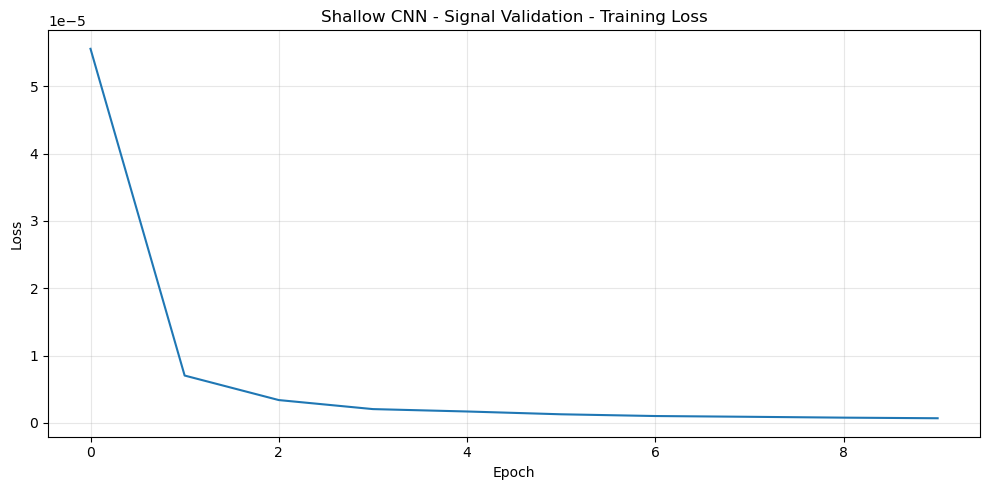

In [ ]:
# full pipeline

print("\\n" + "="*60)
print("PHASE 1: Shallow CNN Training")
print("="*60)

shallow_model = ShallowCNN(input_channels=4, embedding_dim=256)
print(f"Model parameters: {sum(p.numel() for p in shallow_model.parameters()):,}")

# If using contrastive learning, recreate dataloader with augmentation
train_loader_aug = create_dataloader(image_paths, batch_size=4, augment=True)
losses = train_shallow_cnn_contrastive(shallow_model, train_loader_aug, epochs=10, device=device)
# plot_training_curves(losses, model_name='Shallow CNN - Signal Validation')

In [ ]:
# ============================================================================
# SHALLOW CNN: EMBEDDING EXTRACTION, CLUSTERING & VISUALIZATION
# ============================================================================
print("\n" + "="*60)
print("Extracting Embeddings from Shallow CNN")
print("="*60)

# Extract embeddings using the trained Shallow CNN model
embeddings_shallow = extract_embeddings_shallow(
    shallow_model,
    train_loader,  # Use the same dataloader used for training
    device=device
)
print(f"✓ Extracted embeddings shape: {embeddings_shallow.shape}")
print(f"  (n_samples={embeddings_shallow.shape[0]}, embedding_dim={embeddings_shallow.shape[1]})")

# Quick statistics
print(f"\nEmbedding statistics:")
print(f"  Mean: {embeddings_shallow.mean():.3f}")
print(f"  Std: {embeddings_shallow.std():.3f}")
print(f"  Min: {embeddings_shallow.min():.3f}")
print(f"  Max: {embeddings_shallow.max():.3f}")


# ============================================================================
# CLUSTERING ANALYSIS
# ============================================================================
print("\n" + "="*60)
print("Clustering Analysis")
print("="*60)


Extracting Embeddings from Shallow CNN
Image conversion time: 0.6485979557037354 s
Image conversion time: 0.0033669471740722656 s
Image conversion time: 0.3297090530395508 s
Image conversion time: 0.005604267120361328 s
Total elapsed time: 0.9893300533294678 s
Image conversion time: 0.3739631175994873 s
Image conversion time: 0.0022950172424316406 s
Image conversion time: 0.24068307876586914 s
Image conversion time: 0.0044040679931640625 s
Total elapsed time: 0.6226041316986084 s
Image conversion time: 0.38530516624450684 s
Image conversion time: 0.0028400421142578125 s
Image conversion time: 0.23923802375793457 s
Image conversion time: 0.005028247833251953 s
Total elapsed time: 0.6342241764068604 s
Image conversion time: 0.44509077072143555 s
Image conversion time: 0.0028619766235351562 s
Image conversion time: 0.29827880859375 s
Image conversion time: 0.014284849166870117 s
Total elapsed time: 0.762505054473877 s
Image conversion time: 0.45057201385498047 s
Image conversion time: 0.

NameError: name 'silhouette_score' is not defined

In [ ]:
# Find optimal number of clusters
print("\nFinding optimal number of clusters...")
results_shallow = find_optimal_clusters(
    embeddings_shallow,
    max_k=10,
    method='kmeans'
)

# Plot cluster quality metrics (elbow curve + silhouette scores)
plot_cluster_quality(results_shallow)

# Identify optimal k (highest silhouette score)
best_k_idx = np.argmax(results_shallow['silhouette_scores'])
k_optimal_shallow = results_shallow['k_values'][best_k_idx]
print(f"\n✓ Recommended k (highest silhouette): {k_optimal_shallow}")
print(f"  Silhouette score: {results_shallow['silhouette_scores'][best_k_idx]:.3f}")

# Perform clustering with optimal k
print(f"\nClustering with k={k_optimal_shallow}...")
cluster_labels_shallow, cluster_model_shallow = cluster_embeddings(
    embeddings_shallow,
    method='kmeans',
    n_clusters=k_optimal_shallow
)

# Analyze cluster distribution
print("\nCluster distribution:")
unique, counts = np.unique(cluster_labels_shallow, return_counts=True)
for cluster_id, count in zip(unique, counts):
    percentage = 100 * count / len(cluster_labels_shallow)
    print(f"  Cluster {cluster_id}: {count} images ({percentage:.1f}%)")

# Calculate comprehensive cluster quality metrics
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

sil_score = silhouette_score(embeddings_shallow, cluster_labels_shallow)
db_score = davies_bouldin_score(embeddings_shallow, cluster_labels_shallow)
ch_score = calinski_harabasz_score(embeddings_shallow, cluster_labels_shallow)

print("\nCluster quality metrics:")
print(f"  Silhouette Score: {sil_score:.3f} (higher is better, range: [-1, 1])")
print(f"  Davies-Bouldin Index: {db_score:.3f} (lower is better)")
print(f"  Calinski-Harabasz Score: {ch_score:.1f} (higher is better)")


# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n" + "="*60)
print("Visualizing Embeddings in 2D")
print("="*60)

# UMAP visualization
print("\nGenerating UMAP projection...")
embedding_2d_umap_shallow = visualize_embeddings_2d(
    embeddings_shallow,
    labels=cluster_labels_shallow,
    method='umap',
    title=f'Shallow CNN Embeddings - UMAP (k={k_optimal_shallow})',
    save_path='shallow_cnn_embeddings_umap.png'
)

# t-SNE visualization
print("\nGenerating t-SNE projection...")
embedding_2d_tsne_shallow = visualize_embeddings_2d(
    embeddings_shallow,
    labels=cluster_labels_shallow,
    method='tsne',
    title=f'Shallow CNN Embeddings - t-SNE (k={k_optimal_shallow})',
    save_path='shallow_cnn_embeddings_tsne.png'
)


# ============================================================================
# COMPARE MULTIPLE K VALUES
# ============================================================================
print("\n" + "="*60)
print("Comparing Different K Values")
print("="*60)

# Try different k values to visualize cluster separation
k_values_to_try = [3, 4, 5, 6]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# Compute UMAP once for consistent visualization
reducer_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding_2d_comparison = reducer_umap.fit_transform(embeddings_shallow)

for idx, k in enumerate(k_values_to_try):
    print(f"\nClustering with k={k}...")
    labels_k, _ = cluster_embeddings(
        embeddings_shallow,
        method='kmeans',
        n_clusters=k
    )

    # Plot on subplot
    ax = axes[idx]
    unique_labels = np.unique(labels_k)
    cmap = plt.cm.get_cmap('tab10', len(unique_labels))

    for i, label in enumerate(unique_labels):
        mask = labels_k == label
        ax.scatter(embedding_2d_comparison[mask, 0], embedding_2d_comparison[mask, 1],
                  c=[cmap(i)], label=f'Cluster {label}',
                  alpha=0.7, s=50, edgecolors='black', linewidth=0.5)

    sil = silhouette_score(embeddings_shallow, labels_k)
    ax.set_title(f'k={k} (Silhouette: {sil:.3f})', fontsize=12)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(loc='best', fontsize=8)

plt.suptitle('Shallow CNN: Clustering with Different K Values', fontsize=16, y=1.00)
plt.tight_layout()
plt.savefig('shallow_cnn_comparison_k_values.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved comparison plot: shallow_cnn_comparison_k_values.png")


# ============================================================================
# SAVE RESULTS
# ============================================================================
print("\n" + "="*60)
print("Saving Results")
print("="*60)

# Save embeddings
np.save('shallow_cnn_embeddings.npy', embeddings_shallow)
print(f"✓ Saved embeddings: shallow_cnn_embeddings.npy")

# Save cluster labels
np.save('shallow_cnn_cluster_labels.npy', cluster_labels_shallow)
print(f"✓ Saved cluster labels: shallow_cnn_cluster_labels.npy")

# Save 2D projections
np.save('shallow_cnn_umap_2d.npy', embedding_2d_umap_shallow)
np.save('shallow_cnn_tsne_2d.npy', embedding_2d_tsne_shallow)
print(f"✓ Saved 2D projections")

# Save model weights
torch.save(shallow_model.state_dict(), 'shallow_cnn_weights.pth')
print(f"✓ Saved model weights: shallow_cnn_weights.pth")

print("\n" + "="*60)
print("✓ SHALLOW CNN CLUSTERING PIPELINE COMPLETE!")
print("="*60)
print(f"\nSummary:")
print(f"  - Embeddings extracted: {embeddings_shallow.shape}")
print(f"  - Optimal clusters found: {k_optimal_shallow}")
print(f"  - Silhouette score: {sil_score:.3f}")
print(f"  - Visualizations saved: UMAP, t-SNE, k-comparison")


## II. Convolutional Autoencoder Embedder

Once signal has been confirmed, using a more advanced model for smarter clustering

ALERT ALERT, must set augment to FALSE here

In [23]:
class ConvAutoencoder(nn.Module):
    """
    Symmetric convolutional autoencoder for unsupervised embedding learning.
    
    Better than Shallow CNN because:
    - Reconstruction objective forces meaningful representations
    - Deeper architecture learns hierarchical features
    - Bottleneck naturally creates compressed embeddings
    
    Architecture:
        Encoder: 4 conv blocks → 512-dim bottleneck
        Decoder: 4 transpose conv blocks → reconstruct 4 channels
        Loss: MSE reconstruction loss
    """
    def __init__(self, input_channels=4, latent_dim=512):
        super(ConvAutoencoder, self).__init__()
        
        # ENCODER
        # 224x224x4 → 112x112x32
        self.enc1 = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        
        # 112x112x32 → 56x56x64
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        # 56x56x64 → 28x28x128
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        
        # 28x28x128 → 14x14x256
        self.enc4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        
        # Flatten and bottleneck
        self.flatten = nn.Flatten()
        self.fc_enc = nn.Linear(256 * 14 * 14, latent_dim)
        
        # DECODER
        self.fc_dec = nn.Linear(latent_dim, 256 * 14 * 14)
        
        # 14x14x256 → 28x28x128
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        
        # 28x28x128 → 56x56x64
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        # 56x56x64 → 112x112x32
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        
        # 112x112x32 → 224x224x4
        self.dec4 = nn.Sequential(
            nn.ConvTranspose2d(32, input_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output in [0,1] range
        )
        
        self.latent_dim = latent_dim
    
    def encode(self, x):
        """Extract embedding from image"""
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x = self.enc4(x)
        x = self.flatten(x)
        z = self.fc_enc(x)
        return z
    
    def decode(self, z):
        """Reconstruct image from embedding"""
        x = self.fc_dec(z)
        x = x.view(-1, 256, 14, 14)
        x = self.dec1(x)
        x = self.dec2(x)
        x = self.dec3(x)
        x = self.dec4(x)
        return x
    
    def forward(self, x):
        """Full forward pass: encode → decode"""
        z = self.encode(x)
        x_recon = self.decode(z)
        return x_recon, z


def train_conv_autoencoder(model, dataloader, epochs=20, lr=1e-3, device='cpu'):
    """
    Train Convolutional Autoencoder with MSE reconstruction loss.
    """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    model.train()
    losses = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_idx, batch in enumerate(dataloader):
            # Handle paired data or single images
            if isinstance(batch, (list, tuple)):
                images = batch[0]
            else:
                images = batch
            
            images = images.to(device)
            
            # Forward pass
            reconstructions, embeddings = model(images)
            
            # Reconstruction loss
            loss = criterion(reconstructions, images)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Reconstruction Loss: {avg_loss:.6f}")
    
    return losses


def extract_embeddings_autoencoder(model, dataloader, device='cpu'):
    """Extract embeddings from trained autoencoder"""
    model = model.to(device)
    model.eval()
    
    embeddings = []
    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                batch = batch[0]
            batch = batch.to(device)
            z = model.encode(batch)
            embeddings.append(z.cpu().numpy())
    
    return np.vstack(embeddings)

## III. Variantional Autoencoder Embedder

In [27]:
train_loader = create_dataloader(
    image_paths, 
    batch_size=4,  # Adjust based on your GPU memory
    shuffle=True,
    augment=False,  # Set True for Shallow CNN contrastive learning
    num_workers=0,  # Increase if using multiple CPU cores
    target_size=224
)

NameError: name 'transforms' is not defined

In [22]:
class VAE(nn.Module):
    """
    Variational Autoencoder - BEST for unsupervised clustering.
    
    Why VAE is superior for this task:
    1. Structured latent space - regularization forces organization
    2. Natural clustering - similar images cluster together
    3. Probabilistic - captures uncertainty in embeddings
    4. Prevents overfitting - KL divergence acts as regularizer
    5. Interpretable - can sample and interpolate in latent space
    
    Architecture:
        Encoder: Conv layers → mean & log_variance
        Reparameterization: Sample from N(mean, variance)
        Decoder: Reconstruct from sampled latent vector
        Loss: Reconstruction + KL divergence
    """
    def __init__(self, input_channels=4, latent_dim=256):
        super(VAE, self).__init__()
        
        # ENCODER (same as Conv Autoencoder)
        self.enc1 = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        
        self.enc4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        
        self.flatten = nn.Flatten()
        
        # VAE-specific: Output mean and log_variance
        self.fc_mu = nn.Linear(256 * 14 * 14, latent_dim)
        self.fc_logvar = nn.Linear(256 * 14 * 14, latent_dim)
        
        # DECODER
        self.fc_dec = nn.Linear(latent_dim, 256 * 14 * 14)
        
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        
        self.dec4 = nn.Sequential(
            nn.ConvTranspose2d(32, input_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )
        
        self.latent_dim = latent_dim
    
    def encode(self, x):
        """Encode to mean and log_variance"""
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x = self.enc4(x)
        x = self.flatten(x)
        
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick: z = mu + epsilon * sigma
        where epsilon ~ N(0, 1)
        
        This allows backpropagation through sampling
        """
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + epsilon * std
        return z
    
    def decode(self, z):
        """Reconstruct image from latent vector"""
        x = self.fc_dec(z)
        x = x.view(-1, 256, 14, 14)
        x = self.dec1(x)
        x = self.dec2(x)
        x = self.dec3(x)
        x = self.dec4(x)
        return x
    
    def forward(self, x):
        """Full VAE forward pass"""
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


def vae_loss_function(recon_x, x, mu, logvar, beta=1.0):
    """
    VAE loss = Reconstruction loss + KL divergence
    
    Args:
        recon_x: Reconstructed images
        x: Original images
        mu: Mean of latent distribution
        logvar: Log variance of latent distribution
        beta: Weight for KL divergence (beta-VAE)
              - beta=1.0: Standard VAE
              - beta>1.0: Stronger regularization (more disentangled representations)
              - beta<1.0: Weaker regularization (better reconstructions)
    
    Returns:
        total_loss, recon_loss, kl_loss
    """
    # Reconstruction loss (MSE)
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    # KL divergence: KL(N(mu, sigma) || N(0, 1))
    # = 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Total loss
    total_loss = recon_loss + beta * kl_loss
    
    return total_loss, recon_loss, kl_loss


def train_vae(model, dataloader, epochs=30, lr=1e-3, beta=1.0, device='cpu'):
    """
    Train Variational Autoencoder.
    
    Args:
        beta: KL divergence weight
              - Start with beta=0.5 for easier training
              - Increase to beta=1.0-2.0 for better clustering
    """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    model.train()
    losses = {'total': [], 'recon': [], 'kl': []}
    
    for epoch in range(epochs):
        epoch_total = 0
        epoch_recon = 0
        epoch_kl = 0
        
        for batch_idx, batch in enumerate(dataloader):
            if isinstance(batch, (list, tuple)):
                images = batch[0]
            else:
                images = batch
            
            images = images.to(device)
            
            # Forward pass
            reconstructions, mu, logvar = model(images)
            
            # Compute loss
            total_loss, recon_loss, kl_loss = vae_loss_function(
                reconstructions, images, mu, logvar, beta=beta
            )
            
            # Backward pass
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()
            
            # Track losses
            batch_size = images.size(0)
            epoch_total += total_loss.item()
            epoch_recon += recon_loss.item()
            epoch_kl += kl_loss.item()
        
        # Average losses
        num_samples = len(dataloader.dataset)
        avg_total = epoch_total / num_samples
        avg_recon = epoch_recon / num_samples
        avg_kl = epoch_kl / num_samples
        
        losses['total'].append(avg_total)
        losses['recon'].append(avg_recon)
        losses['kl'].append(avg_kl)
        
        print(f"Epoch {epoch+1}/{epochs}, Total: {avg_total:.4f}, "
              f"Recon: {avg_recon:.4f}, KL: {avg_kl:.4f}")
    
    return losses


def extract_embeddings_vae(model, dataloader, use_mean=True, device='cpu'):
    """
    Extract embeddings from trained VAE.
    
    Args:
        use_mean: If True, use mu (deterministic)
                  If False, sample from distribution (stochastic)
    
    For clustering, use_mean=True is recommended for consistency.
    """
    model = model.to(device)
    model.eval()
    
    embeddings = []
    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                batch = batch[0]
            batch = batch.to(device)
            
            mu, logvar = model.encode(batch)
            
            if use_mean:
                z = mu
            else:
                z = model.reparameterize(mu, logvar)
            
            embeddings.append(z.cpu().numpy())
    
    return np.vstack(embeddings)

In [ ]:
vae = VAE(input_channels=4, latent_dim=256)
print(f"Model parameters: {sum(p.numel() for p in vae.parameters()):,}")

losses_vae = train_vae(
    vae, 
    train_loader, 
    epochs=30,  # Increase to 50-100 for best results
    lr=1e-3,
    beta=0.5,  # Start with lower beta, increase gradually
    device=device
)

# Plot training curves
plot_training_curves(losses_vae, model_name='VAE')

In [ ]:
# Visualize reconstructions
visualize_reconstructions(vae, train_loader, n_samples=3, 
                         model_type='vae', device=device)

# Visualize random samples from latent space
visualize_latent_space_sampling(vae, n_samples=5, latent_dim=256, device=device)

In [ ]:
embeddings = extract_embeddings_vae(vae, train_loader, use_mean=True, device=device)
print(f"Extracted embeddings shape: {embeddings.shape}")

In [ ]:
# Find optimal number of clusters
results = find_optimal_clusters(embeddings, max_k=10, method='kmeans')
plot_cluster_quality(results)

In [ ]:
# Use recommended k or choose your own
k_optimal = 5  # Adjust based on plot

# Perform clustering
cluster_labels, cluster_model = cluster_embeddings(
    embeddings, 
    method='kmeans',  # or 'dbscan', 'hierarchical'
    n_clusters=k_optimal
)

In [ ]:
# Do this last probably, confirm a general signal first

metadata_df = # df with subject, freq, group, etc. grab this from last year's notebook....
analyze_clusters(embeddings, cluster_labels, metadata_df, 
                metadata_cols=['Subject', 'Group'])

In [ ]:
# UMAP visualization
embedding_2d_umap = visualize_embeddings_2d(
    embeddings, 
    labels=cluster_labels,
    method='umap',
    title='VAE Embeddings - UMAP Projection',
    save_path='embeddings_umap.png'
)

# t-SNE visualization
embedding_2d_tsne = visualize_embeddings_2d(
    embeddings, 
    labels=cluster_labels,
    method='tsne',
    title='VAE Embeddings - t-SNE Projection',
    save_path='embeddings_tsne.png'
)